In [1]:
import pandas as pd

url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"
url_2k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/2k.csv"
url_4k7 = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/4k7.csv"

load_1k = pd.read_csv(
    url_1k,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

load_1k.columns = [
    "time",
    "dac",
    "shunt"
]

load_1k = load_1k.astype(float)

load_2k = pd.read_csv(
    url_2k,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

load_2k.columns = [
    "time",
    "dac",
    "shunt"
]

load_2k = load_2k.astype(float)

load_4k7 = pd.read_csv(
    url_4k7,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

load_4k7.columns = [
    "time",
    "dac",
    "shunt"
]

load_4k7 = load_4k7.astype(float)

ModuleNotFoundError: No module named 'pandas'

<Axes: xlabel='time'>

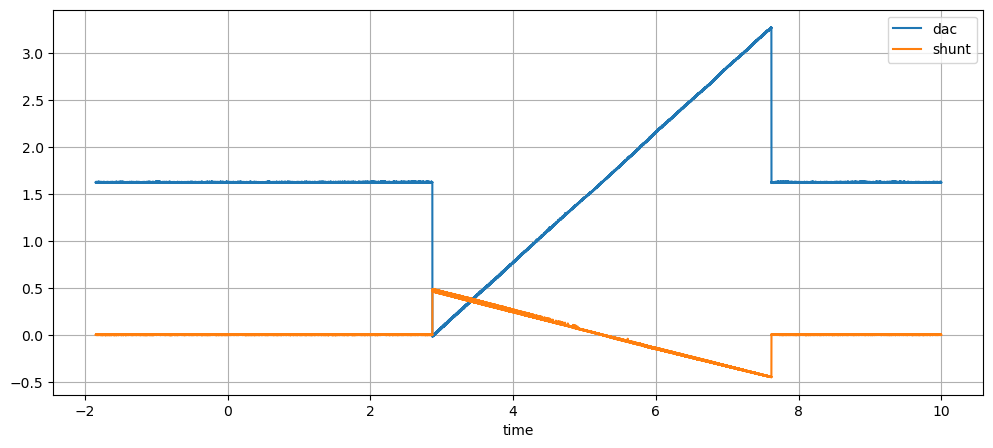

In [ ]:
load_1k.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True
)

In [ ]:
def extract_linear_region(df, column="dac", rest_value=1.65, tolerance=1):

    filtered_df = df[
        (df[column] < rest_value - tolerance) |
        (df[column] > rest_value + tolerance)
    ].copy()

    return filtered_df.iloc[1:-1].copy()

In [ ]:
load_1k = extract_linear_region(load_1k, column="dac")
load_2k = extract_linear_region(load_2k, column="dac")
load_4k7 = extract_linear_region(load_4k7, column="dac")

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

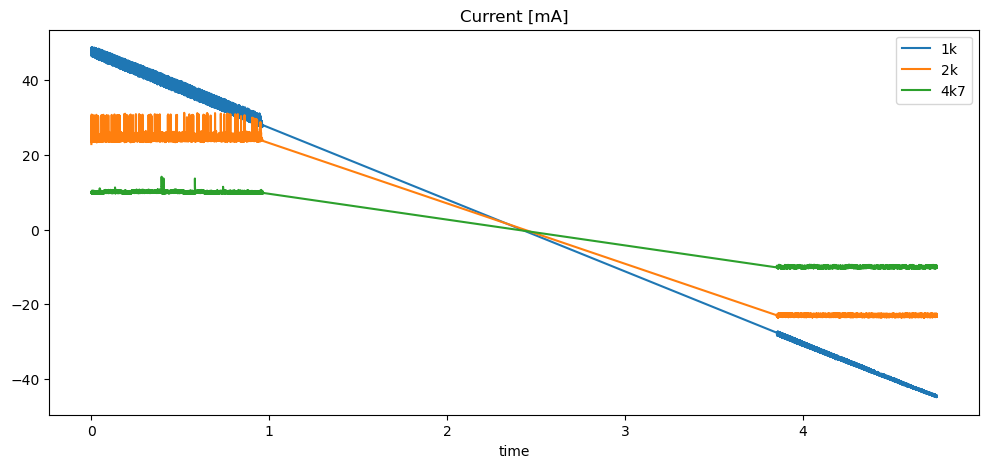

In [ ]:
load_1k["current"] = ( load_1k["shunt"] / 10 ) * 1000
load_2k["current"] = ( load_2k["shunt"] / 10 ) * 1000
load_4k7["current"] = ( load_4k7["shunt"] / 10 ) * 1000

load_1k["time"] = load_1k["time"] - load_1k["time"].iloc[0]
load_2k["time"] = load_2k["time"] - load_2k["time"].iloc[0]
load_4k7["time"] = load_4k7["time"] - load_4k7["time"].iloc[0]

ax = load_1k.plot(
    x="time",
    y="current",
    figsize=(12, 5),
    grid=True,
    title="Current [mA]",
    label="1k"
)

load_2k.plot(
    x="time",
    y="current",
    ax=ax,
    label="2k"
)

load_4k7.plot(
    x="time",
    y="current",
    ax=ax,
    label="4k7"
)

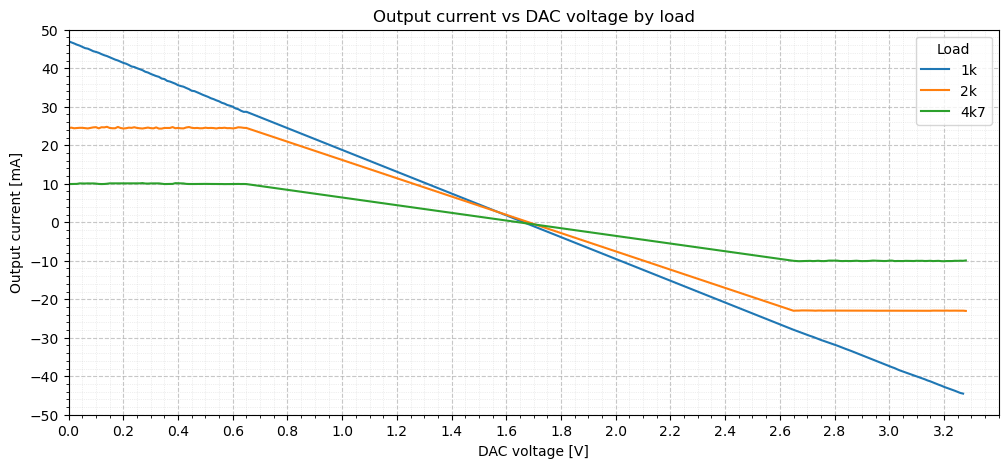

In [ ]:
import numpy as np

dac_step = 0.01  # voltage step

load_1k_cmp = load_1k.copy()
load_2k_cmp = load_2k.copy()
load_4k7_cmp = load_4k7.copy()

load_1k_cmp["load"] = "1k"
load_2k_cmp["load"] = "2k"
load_4k7_cmp["load"] = "4k7"

all_data = pd.concat(
    [load_1k_cmp, load_2k_cmp, load_4k7_cmp],
    ignore_index=True
)

all_data["dac_bin"] = (
    (all_data["dac"] / dac_step)
    .round() * dac_step
)

comparison = all_data.pivot_table(
    index="dac_bin",
    columns="load",
    values="current",
    aggfunc="mean"
)

# =========================================================
# Plot
# =========================================================

ax = comparison.plot(
    figsize=(12, 5)
)

# =========================================================
# X axis
# =========================================================

ax.set_xlim(0, 3.4)

ax.set_xticks(
    np.arange(0, 3.4, 0.2)
)

# =========================================================
# Y axis
# =========================================================

ax.set_ylim(-50, 50)

ax.set_yticks(
    range(-50, 51, 10)
)

# =========================================================
# Grid
# =========================================================

ax.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.7
)

# Optional minor grid
ax.minorticks_on()

ax.grid(
    which="minor",
    linestyle=":",
    linewidth=0.5,
    alpha=0.4
)

# =========================================================
# Labels and title
# =========================================================

ax.set_xlabel("DAC voltage [V]")

ax.set_ylabel("Output current [mA]")

ax.set_title(
    "Output current vs DAC voltage by load"
)

# =========================================================
# Legend
# =========================================================

ax.legend(
    title="Load"
)

In [ ]:
comparison["max_current"] = comparison[["1k", "2k", "4k7"]].max(axis=1)
comparison["min_current"] = comparison[["1k", "2k", "4k7"]].min(axis=1)
comparison["current_spread"] = comparison["max_current"] - comparison["min_current"]

comparison[["1k", "2k", "4k7", "current_spread"]].head()

load,1k,2k,4k7,current_spread
dac_bin,,,,
-0.00,46.806648,24.460979,9.921366,36.885282
0.05,45.593436,24.465374,10.051694,35.541742
0.10,44.213150,24.573423,10.006303,34.206848
0.15,42.820679,24.543492,10.040730,32.779949
0.20,41.404213,24.508461,10.092291,31.311922


In [ ]:
comparison["current_spread"].describe()

count    28.000000
mean     26.409320
std       6.035261
min      13.104080
25%      21.717231
50%      26.532669
75%      31.295348
max      36.885282
Name: current_spread, dtype: float64

<Axes: title={'center': 'Current spread between loads'}, xlabel='dac_bin'>

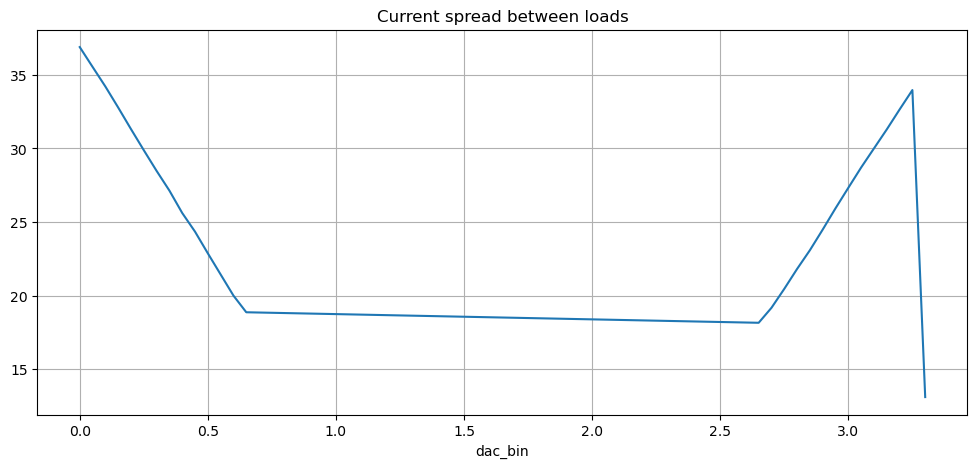

In [ ]:
comparison["current_spread"].plot(
    figsize=(12, 5),
    grid=True,
    title="Current spread between loads"
)

In [ ]:
load_1k["current"].describe()

count    23187.000000
mean         2.107134
std         37.474100
min        -44.846875
25%        -36.018750
50%         29.001563
75%         38.307812
max         48.792187
Name: current, dtype: float64